# Lab 7 - Language Perception

Today we are going to be creating a pipeline for **language perception**. Given a dataset of news articles, our goal is to preprocess them, extract features, and train models. Then we will apply our pipeline to new data as a system that can sort articles into appropriate categories.

First, we will install and import the required libraries.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
%cd /content/drive/MyDrive/Second Term NTU/Artificial_Perception/Lecture_7

/content/drive/MyDrive/Second Term NTU/Artificial_Perception/Lecture_7


In [42]:
!pip install scikit-learn nltk

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Now that everything is imported, we will download the 20 Newsgroups dataset.

While it downloads, read through some of the data here: https://huggingface.co/datasets/SetFit/20_newsgroups

**Point of reflection:** why are we removing headers and footers? What might the model learn if we didn't remove metadata?


In [44]:
'''
print("Downloading dataset...")
data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)
print("Dataset downloaded.")

X = data.data
y = data.target
target_names = data.target_names

print("Number of documents:", len(X))
print("Number of categories:", len(target_names))
print("Categories:", target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
'''

'\nprint("Downloading dataset...")\ndata = fetch_20newsgroups(\n    subset=\'all\',\n    remove=(\'headers\', \'footers\', \'quotes\')\n)\nprint("Dataset downloaded.")\n\nX = data.data\ny = data.target\ntarget_names = data.target_names\n\nprint("Number of documents:", len(X))\nprint("Number of categories:", len(target_names))\nprint("Categories:", target_names)\n\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.3, random_state=42, stratify=y\n)\nprint("Training samples:", len(X_train))\nprint("Testing samples:", len(X_test))\n'

In [46]:
print("Downloading dataset...")

try:
    from sklearn.datasets import fetch_20newsgroups
    data = fetch_20newsgroups(
        subset='all',
        remove=('headers', 'footers', 'quotes')  # lab uses this to avoid metadata leakage
    )
    X, y = data.data, data.target
    target_names = data.target_names

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print("Dataset downloaded.")

except Exception as e:
    print("Download failed:", e)
    print("Falling back to Hugging Face mirror...")

    # NOTE: The lab shows a fallback that may error on label names.
    # This block mirrors the lab but adds two safe lines so it doesn't crash.
    from datasets import load_dataset
    ds_train = load_dataset("SetFit/20_newsgroups", split="train")
    ds_test  = load_dataset("SetFit/20_newsgroups", split="test")

    X_train, y_train = ds_train["text"],  ds_train["label"]
    X_test,  y_test  = ds_test["text"],   ds_test["label"]

    # SAFE ADDITION (prevents AttributeError shown in the PDF output):
    label_feat = ds_train.features.get("label", None)
    target_names = label_feat.names if hasattr(label_feat, "names") else [f"class_{i}" for i in sorted(set(y_train) | set(y_test))]

print("Training samples:", len(X_train))
print("Testing samples: ", len(X_test))

Download failed: HTTP Error 403: Forbidden
Falling back to Hugging Face mirror...


Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


Training samples: 11314
Testing samples:  7532


# Bag of Words (BoW) Representation

If you need a reminder on the BoW approach, check the lecture slides. Alternatively, a brief explanation can be found on Wikipedia: https://en.wikipedia.org/wiki/Bag-of-words_model

Questions:
1.   How many features are present in our dataset?
2.   Does the BoW approach result in a dense or a sparse dataset?
3.   Why do we fit and transform on X_train but only transform X_test? (see the comments in the code below)


In [47]:
print("Building Bag of Words representation...")
vectoriser_bow = CountVectorizer(
    stop_words='english',
    lowercase=True
)
print("Finished generating BoW.")

X_train_bow = vectoriser_bow.fit_transform(X_train) # Note that we fit and transform on X_train...
X_test_bow = vectoriser_bow.transform(X_test) # But only transform on X_test!

print("BoW Data Shape:", X_train_bow.shape)

Building Bag of Words representation...
Finished generating BoW.
BoW Data Shape: (11314, 101322)


Let's train a simple model on our data...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


BoW SVC Model Accuracy: 0.5862984599044079
              precision    recall  f1-score   support

     class_0       0.41      0.40      0.40       319
     class_1       0.54      0.61      0.57       389
     class_2       0.56      0.57      0.57       394
     class_3       0.50      0.53      0.52       392
     class_4       0.61      0.59      0.60       385
     class_5       0.73      0.62      0.67       395
     class_6       0.70      0.73      0.72       390
     class_7       0.43      0.71      0.53       396
     class_8       0.62      0.66      0.64       398
     class_9       0.74      0.70      0.72       397
    class_10       0.76      0.78      0.77       399
    class_11       0.73      0.62      0.67       396
    class_12       0.51      0.44      0.47       393
    class_13       0.69      0.61      0.65       396
    class_14       0.64      0.61      0.63       394
    class_15       0.59      0.59      0.59       398
    class_16       0.52      0.49     

<Figure size 4000x3600 with 0 Axes>

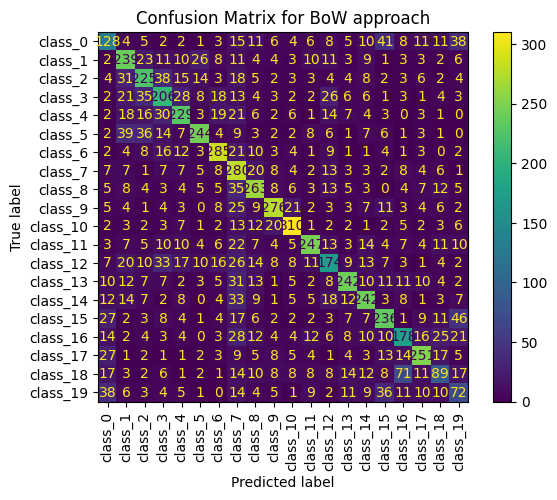

In [48]:
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


model_bow = LinearSVC()
model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_test_bow)

print("BoW SVC Model Accuracy:", accuracy_score(y_test, pred_bow))
print(classification_report(y_test, pred_bow, target_names=target_names))

cm = confusion_matrix(y_test, pred_bow)
plt.figure(figsize=(20, 18), dpi=200)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix for BoW approach")
plt.show()

# Point of Reflection
Observe the report and confusion matrix above. Which categories experienced the worst classification? Of those categories, where did the confusion occur? (e.g., were they mixed up with a related category?)


---


# Task 1 - TF-IDF
Your task is to repeat the above implementation of the Linear SVC, but this time, you will use the TF-IDF representation.
The documentation for the TF-IDF vectoriser can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

Repeat the above implementation but with a dataset of TF-IDF features.

**Reflection:** which approach performed best? Why do you think that might be?

In [49]:
# write your code here!
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Build TF-IDF representation
print("Building TF-IDF representation...")

vectoriser_tfidf = TfidfVectorizer(
    stop_words='english',
    lowercase=True
)

X_train_tfidf = vectoriser_tfidf.fit_transform(X_train)
X_test_tfidf = vectoriser_tfidf.transform(X_test)

print("TF-IDF Data Shape:", X_train_tfidf.shape)

# 2. Train Linear SVC on TF-IDF features
model_tfidf = LinearSVC()
model_tfidf.fit(X_train_tfidf, y_train)

# 3. Predict on test set
pred_tfidf = model_tfidf.predict(X_test_tfidf)

# 4. Print results
print("TF-IDF SVC Model Accuracy:", accuracy_score(y_test, pred_tfidf))
print(classification_report(y_test, pred_tfidf, target_names=target_names))

Building TF-IDF representation...
TF-IDF Data Shape: (11314, 101322)
TF-IDF SVC Model Accuracy: 0.692777482740308
              precision    recall  f1-score   support

     class_0       0.55      0.49      0.52       319
     class_1       0.68      0.74      0.71       389
     class_2       0.62      0.62      0.62       394
     class_3       0.63      0.65      0.64       392
     class_4       0.73      0.70      0.71       385
     class_5       0.83      0.70      0.76       395
     class_6       0.73      0.78      0.76       390
     class_7       0.74      0.71      0.73       396
     class_8       0.78      0.75      0.77       398
     class_9       0.55      0.85      0.66       397
    class_10       0.87      0.87      0.87       399
    class_11       0.86      0.72      0.78       396
    class_12       0.63      0.58      0.60       393
    class_13       0.80      0.77      0.78       396
    class_14       0.75      0.75      0.75       394
    class_15       0.

# Testing for failure
Below we are going to predict the category of three strings of data - one about a children's film, one about NASA launching satellites, and the third is about an election taking place in France.

**Your task:** Below, I have used the BoW model to predict the classes. After completing the above task, you should have a second vectoriser and model for the TF-IDF representation. Implement your TF-IDF predictor within the loop below, just as I have done for BoW.

In [50]:
test_strings = [
    "This animated movie is about a robot who has lost his processor. He goes on an adventure to find his lost CPU, and gains some RAM along the way.",
    "NASA has launched a set of new satellites this morning from the Kennedy Space Center at Cape Canaveral, Flordia.",
    "French voters are set to go to the polls this morning in what could be the most exciting election of this generation."
]

for test_string in test_strings:
  print(test_string)
  bow_pred = model_bow.predict(vectoriser_bow.transform([test_string]))
  print("BoW Prediction:", target_names[bow_pred[0]])

  tfidf_pred = model_tfidf.predict(vectoriser_tfidf.transform([test_string]))
  print("TF-IDF Prediction:", target_names[tfidf_pred[0]], "\n")

This animated movie is about a robot who has lost his processor. He goes on an adventure to find his lost CPU, and gains some RAM along the way.
BoW Prediction: class_6
TF-IDF Prediction: class_3 

NASA has launched a set of new satellites this morning from the Kennedy Space Center at Cape Canaveral, Flordia.
BoW Prediction: class_14
TF-IDF Prediction: class_14 

French voters are set to go to the polls this morning in what could be the most exciting election of this generation.
BoW Prediction: class_18
TF-IDF Prediction: class_18 



# Testing on a real-world article

Briefly read this article: https://news.sky.com/story/four-new-astronauts-arrive-at-the-international-space-station-to-replace-evacuated-crew-13507767

Which of our categories do you think this article should belong to?

In the NOW Learning room, I have created a raw text file containing this article called "Article_ISS.txt". Ensure that this file is either uploaded to Colab/Kaggle or in the same local location as this Python Notebook.


**Your task:** as above, the below code makes a prediction using the BoW appraoch. Include your TF-IDF predictor here too.

In [51]:
with open('Article_ISS.txt', 'r') as file:
  article = file.read()

bow_pred = model_bow.predict(vectoriser_bow.transform([article]))
print("BoW Prediction:", target_names[bow_pred[0]])

tfidf_pred = model_tfidf.predict(vectoriser_tfidf.transform([article]))
print("TF-IDF Prediction:", target_names[tfidf_pred[0]], "\n")

BoW Prediction: class_14
TF-IDF Prediction: class_14 



Find a news article online. Copy and paste the text into a new file called "my_article.txt". Run the below code to test how the models categorise it.

Note: try to find a challenging article with *nuance* between categories.

Do you agree with the model's prediction? If not, which category do you think would be a better fit?

In [55]:
with open('my_article.txt', 'r') as file:
  article = file.read()

bow_pred = model_bow.predict(vectoriser_bow.transform([article]))
print("BoW Prediction:", target_names[bow_pred[0]])

tfidf_pred = model_tfidf.predict(vectoriser_tfidf.transform([article]))
print("TF-IDF Prediction:", target_names[tfidf_pred[0]], "\n")

BoW Prediction: class_14
TF-IDF Prediction: class_14 



# Training Multiple Classifiers
Similarly to last week, we will now train multiple classifiers on the data.

Note: our dataset is large, and so I have chosen relatively simple classifiers in the interest of time.

Research the models available from Scikit Learn and implement them here. Reflect on the tradeoff between training time and classification ability, if any.

In [56]:
import time
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = [
    ("LinearSVC", LinearSVC()),
    ("MultinomialNB", MultinomialNB()),
    ("RandomForest (50)", RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ("KNN (5)", KNeighborsClassifier(n_neighbors=5)),
    # Add more models here!
    ("KNN (6)", KNeighborsClassifier(n_neighbors=6))
]

for name, model in models:
  print("Training: ", name)
  start = time.time()
  model.fit(X_train_bow, y_train)
  end = time.time()
  print("Finished in: ", end - start, "seconds")

  pred = model.predict(X_test_bow)
  acc = accuracy_score(y_test, pred)
  precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
  print("F1 score: ", f1, "\n")

Training:  LinearSVC


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Finished in:  8.790498495101929 seconds
F1 score:  0.5760457484592807 

Training:  MultinomialNB
Finished in:  0.3458716869354248 seconds
F1 score:  0.5967678797787761 

Training:  RandomForest (50)
Finished in:  69.3394603729248 seconds
F1 score:  0.5784924755977874 

Training:  KNN (5)
Finished in:  0.1841106414794922 seconds
F1 score:  0.1972535537345424 

Training:  KNN (6)
Finished in:  0.19379949569702148 seconds
F1 score:  0.20105563030021742 



# Linear Search for Hyperparameters

Given that we have spoken about hyperparameter selection over the last few weeks, the below code has been included to show a simple hyperparameter search. In KNN, we test *k = {2,...,15}*.

**Point of reflection:** what pattern can you see in the results? Which value of k was best?


Training and testing k= 2
Training and testing k= 3
Training and testing k= 4
Training and testing k= 5
Training and testing k= 6
Training and testing k= 7
Training and testing k= 8
Training and testing k= 9
Training and testing k= 10
Training and testing k= 11
Training and testing k= 12
Training and testing k= 13
Training and testing k= 14
Training and testing k= 15


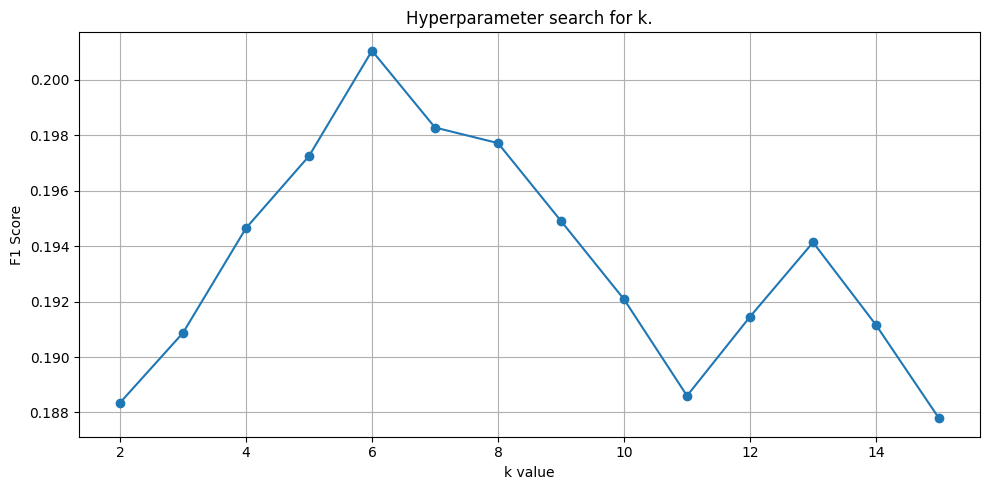

In [57]:
ks = []
f1s = []

for k in range(2,16):
  print("Training and testing k=", k)

  knn = KNeighborsClassifier(n_neighbors=k)

  knn.fit(X_train_bow, y_train)

  pred = knn.predict(X_test_bow)
  precision, recall, f1, _ = precision_recall_fscore_support(
      y_test, pred, average="macro", zero_division=0
  )

  ks.append(k)
  f1s.append(f1)


plt.figure(figsize=(10, 5))
plt.plot(ks, f1s, marker="o", linestyle="-")
plt.xlabel("k value")
plt.ylabel("F1 Score")
plt.title("Hyperparameter search for k.")
plt.grid(True)
plt.tight_layout()
plt.show()

# Task 2 - Classifiers and *k=?* search on TF-IDF.

Repeat the above **two** blocks of code for the TF-IDF vectoriser and dataset.
1.   When training multiple classifiers (e.g., SVC, NB, RF, KNN, etc.), which performs best and on which data? Earlier, you may have noticed that TF-IDF tends to outperform BoW on this dataset, but are there any models that perform better with BoW?
2.   During the linear search for the best value of k in KNN, does TF-IDF experience a similar pattern or are there differences to BoW?



In [58]:
# Training multiple classifiers. Write your code here.
# Task 2.1: Multiple classifiers on TF-IDF
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models_tfidf = [
    ("LinearSVC", LinearSVC()),
    ("MultinomialNB", MultinomialNB()),
    ("RandomForest (50)", RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
    ("KNN (5)", KNeighborsClassifier(n_neighbors=5)),
    # (Optional) Add others, e.g., LogisticRegression(max_iter=2000)
]

results_tfidf = []

for name, model in models_tfidf:
    print("Training: ", name)
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    end = time.time()
    print("Finished in: ", end - start, "seconds")

    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    print("Accuracy: ", acc)
    print("F1 score: ", f1, "\n")

    results_tfidf.append((name, acc, f1, end - start))

Training:  LinearSVC
Finished in:  6.23462986946106 seconds
Accuracy:  0.692777482740308
F1 score:  0.6814581981836018 

Training:  MultinomialNB
Finished in:  0.2799255847930908 seconds
Accuracy:  0.6779075942644716
F1 score:  0.6467991505900852 

Training:  RandomForest (50)
Finished in:  69.00980591773987 seconds
Accuracy:  0.6090015932023367
F1 score:  0.5915283784064158 

Training:  KNN (5)
Finished in:  0.1657242774963379 seconds
Accuracy:  0.07766861391396708
F1 score:  0.07143002304009125 



Training and testing k= 2
Training and testing k= 3
Training and testing k= 4
Training and testing k= 5
Training and testing k= 6
Training and testing k= 7
Training and testing k= 8
Training and testing k= 9
Training and testing k= 10
Training and testing k= 11
Training and testing k= 12
Training and testing k= 13
Training and testing k= 14
Training and testing k= 15


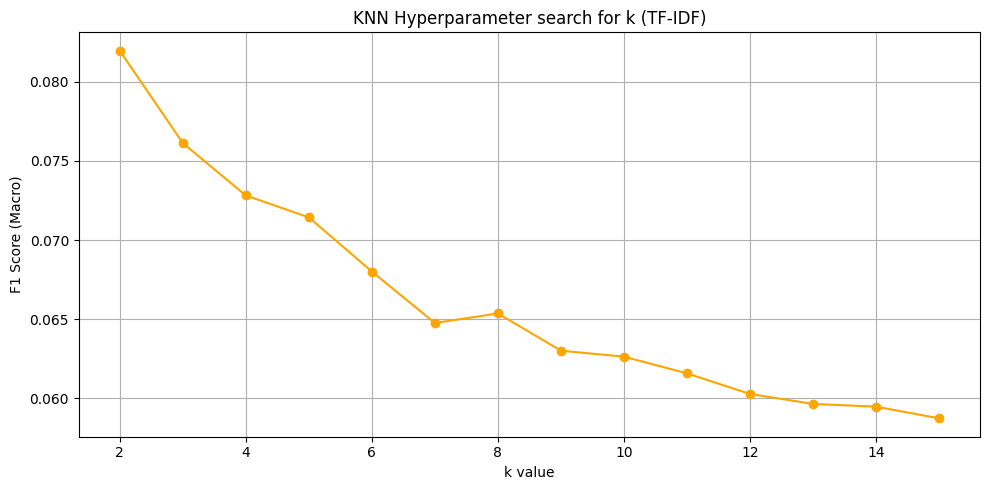

In [59]:
# Searching for values of k. Write your code here.
# Task 2.2: KNN k-search on TF-IDF
from sklearn.neighbors import KNeighborsClassifier
ks_tfidf, f1s_tfidf = [], []

for k in range(2, 16):
    print("Training and testing k=", k)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_tfidf, y_train)
    pred = knn.predict(X_test_tfidf)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    ks_tfidf.append(k)
    f1s_tfidf.append(f1)

plt.figure(figsize=(10, 5))
plt.plot(ks_tfidf, f1s_tfidf, marker="o", linestyle="-", color="orange")
plt.xlabel("k value")
plt.ylabel("F1 Score (Macro)")
plt.title("KNN Hyperparameter search for k (TF-IDF)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Stemming

By now, you will have realised that this dataset is quite complex. For example, the BoW approach resulted in **118,372** features! In the lecture, we looked at stemming and lemmatisation. Below, we are going to implement stemming and see the difference it makes to our BoW approach.

**Important:** before moving on, briefly read the NLTK sample usage for the PorterStemmer - https://www.nltk.org/howto/stem.html

First, let's preprocess the dataset by stemming each word, then, we will need to rebuild our dataset.

In [60]:
from nltk.stem import PorterStemmer
import re

stemmer = PorterStemmer()

def stem_text(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    stemmed = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed)

print("Stemming training data...")
X_train_stem = [stem_text(doc) for doc in X_train]
X_test_stem = [stem_text(doc) for doc in X_test]


vectoriser_stem = CountVectorizer(stop_words='english')

X_train_bow_stem = vectoriser_stem.fit_transform(X_train_stem)
X_test_bow_stem = vectoriser_stem.transform(X_test_stem)

print("Original vocabulary (features):", len(vectoriser_bow.vocabulary_))
print("Stemmed vocabulary:", len(vectoriser_stem.vocabulary_))

reduced = (len(vectoriser_bow.vocabulary_) - len(vectoriser_stem.vocabulary_)) / len(vectoriser_bow.vocabulary_)
reduced = reduced*100
reduced = round(reduced, 2)

print("The features have been reduced by", reduced, "%!")

Stemming training data...
Original vocabulary (features): 101322
Stemmed vocabulary: 83830
The features have been reduced by 17.26 %!


# Task 3 - Benchmarking on Stemmed Text

Now that we have reduced our dataset, repeat the "Training Multiple Classifiers" code for the X_train_bow_stem and X_test_bow_stem.

**Reflection:** is the training time reduced? If so, does it come at a cost or have the results actually improved?

In [61]:
# Write your code here
# Benchmark common classifiers on the STEMMED BoW features
import time
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

models_stem = [
    ("LinearSVC", LinearSVC()),
    ("MultinomialNB", MultinomialNB()),
    ("RandomForest (50)", RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
]

results_stem = []

for name, clf in models_stem:
    print(f"Training on STEMMED BoW: {name}")
    t0 = time.time()
    clf.fit(X_train_bow_stem, y_train)
    t1 = time.time()

    pred = clf.predict(X_test_bow_stem)
    acc = accuracy_score(y_test, pred)
    _, _, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)

    print(f"  Time: {t1 - t0:.2f}s | Accuracy: {acc:.4f} | Macro-F1: {f1:.4f}\n")
    results_stem.append((name, acc, f1, t1 - t0))

Training on STEMMED BoW: LinearSVC


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Time: 20.35s | Accuracy: 0.5887 | Macro-F1: 0.5804

Training on STEMMED BoW: MultinomialNB
  Time: 0.26s | Accuracy: 0.6232 | Macro-F1: 0.5848

Training on STEMMED BoW: RandomForest (50)
  Time: 62.79s | Accuracy: 0.5932 | Macro-F1: 0.5732



# Feature Selection Example

Even after stemming the text, our dataset is still very large and very sparse. Many words in the dataset **do not matter** for our task. Think back to the lecture slides on choosing to lose data when it is task-specific.

In the below code, I have included chi-square testing to keep only the top n words in the dataset, removing the rest. In the example, I have chosen 3000 words. Note that this selection is arbitrary, and should be explored further.

For more information, see:
https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html

In [62]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=3000) # keep only the top 3000 words

X_train_selected = selector.fit_transform(X_train_bow, y_train)
X_test_selected = selector.transform(X_test_bow)

print("Original dataset:", X_train_bow.shape)
print("Reduced data:", X_train_selected.shape)

example_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training on reduced data...")
start = time.time()
example_model.fit(X_train_selected, y_train)
end = time.time()
time_taken = end - start
print("Finished in: ", time_taken, "seconds")

pred_fs = example_model.predict(X_test_selected)
print("Accuracy:", accuracy_score(y_test, pred_fs), "\n")

print("Training on BoW dataset...")
start = time.time()
example_model.fit(X_train_bow, y_train)
end = time.time()
time_taken = end - start
print("Finished in: ", time_taken, "seconds")

pred_bow = example_model.predict(X_test_bow)
print("Accuracy:", accuracy_score(y_test, pred_bow))

Original dataset: (11314, 101322)
Reduced data: (11314, 3000)
Training on reduced data...
Finished in:  11.38560676574707 seconds
Accuracy: 0.5612055231014339 

Training on BoW dataset...
Finished in:  65.88199877738953 seconds
Accuracy: 0.5981147105682422


**But what if those values are extreme?** In the below code, I have selected only the top 100 words. Considering our original dataset contained 118,372 features, reducing down to 100 means we only retain 0.08% of the data! 99.92% of the data has been **deleted**.

How does the model perform on such a small number of features? Consider your answer in terms of classification ability and resource usage (time taken).

**Point of Reflection:** what kind of text data do you think could be reduced this much but still be effective?

In [63]:
selector = SelectKBest(chi2, k=100) # keep only the top 100 words

X_train_selected = selector.fit_transform(X_train_bow, y_train)
X_test_selected = selector.transform(X_test_bow)

print("Reduced data:", X_train_selected.shape)

example_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training on reduced data...")
start = time.time()
example_model.fit(X_train_selected, y_train)
end = time.time()
time_taken = end - start
print("Finished in: ", time_taken, "seconds")

pred_fs = example_model.predict(X_test_selected)
print("Accuracy:", accuracy_score(y_test, pred_fs), "\n")

Reduced data: (11314, 100)
Training on reduced data...
Finished in:  1.050537347793579 seconds
Accuracy: 0.3432023366967605 



# Stretch Task - Hyperparameter Optimisation for Feature Selection

Go back and look at the example of "Linear Search for Hyperparameters" where we looked through values of k to find the best approach.

You will now repeat that process but for feature selection.

This will help us answer the question, "how many words should we retain in our dataset?".

Hint: you will need to:
1.   Use the Selector to reduce the dataset (fit and transform, then transform)
2.   Train and evaluate the model
3.   Record the F1 score in the f1s list

*Note: much of the code you require to use can be found in various blocks from this tutorial. If you are unsure, look back at the previous tasks or ask your tutor for further guidance.*

**Point of reflection:** is there a particular number of words that are effective for this dataset?



In [ ]:
# Stretch Task - Hyperparameter Optimisation for Feature Selection (as in the lab)
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt


words_retained = []
f1s = []

model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1) # feel free to change this model to another one of your choice!

for words_to_keep in range(100,20000,500):
  print("Training on", words_to_keep, "words...")

  words_retained.append(words_to_keep)

  selector = SelectKBest(chi2, k=words_to_keep) # Selector implemented for you
  # Write your code here

  X_train_selected = selector.fit_transform(X_train_bow, y_train)
  X_test_selected  = selector.transform(X_test_bow)

  model.fit(X_train_selected, y_train)
  pred = model.predict(X_test_selected)

  _, _, f1, _ = precision_recall_fscore_support(
      y_test, pred, average="macro", zero_division=0
  )
  f1s.append(f1)
  # --- End completed section ---


# Results display, implemented for you.
plt.figure(figsize=(10, 5))
plt.plot(words_retained, f1s, marker="o", linestyle="-")
plt.xlabel("Words Retained")
plt.ylabel("F1 Score")
plt.title("Hyperparameter search for words to keep.")
plt.grid(True)
plt.tight_layout()
plt.show()

Training on 100 words...
Training on 600 words...
Training on 1100 words...
Training on 1600 words...
Training on 2100 words...
Training on 2600 words...
Training on 3100 words...
Training on 3600 words...
Training on 4100 words...
Training on 4600 words...
Training on 5100 words...
Training on 5600 words...
Training on 6100 words...
Training on 6600 words...
Training on 7100 words...
Training on 7600 words...
Training on 8100 words...
Training on 8600 words...
Training on 9100 words...
Training on 9600 words...
Training on 10100 words...
Training on 10600 words...
Training on 11100 words...
Training on 11600 words...
Training on 12100 words...
Training on 12600 words...
Training on 13100 words...
Training on 13600 words...
Training on 14100 words...
Training on 14600 words...
Training on 15100 words...
Training on 15600 words...
Training on 16100 words...
Training on 16600 words...
Training on 17100 words...
Training on 17600 words...
Training on 18100 words...
Training on 18600 words